In [1]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import muon as mu
import scirpy as ir
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches

import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

%load_ext rpy2.ipython

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packag

In [ ]:
path = '/home/jupyter/data/ge_korea/notebooks_2025/manuscript_nbs/main_figs'
import shutil
shutil.make_archive(path, 'zip', path)

In [2]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_tnk_annotation_new.h5ad')

In [3]:
tcr = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new_correct_progression.h5ad')

In [4]:
tcr

AnnData object with n_obs × n_vars = 66813 × 36601
    obs: 'sample_x', 'patient', 'timepoint', 'normal', 'batch', 'is_cell', 'high_confidence', 'multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call', 'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_consensus_count', 'IR_VJ_2_consensus_count', 'IR_VDJ_1_consensus_count', 'IR_VDJ_2_consensus_count', 'IR_VJ_1_d_call', 'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call', 'IR_VJ_1_duplicate_count', 'IR_VJ_2_duplicate_count', 'IR_VDJ_1_duplicate_count', 'IR_VDJ_2_duplicate_count', 'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call', 'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction', 'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa', 'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa', 'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus', 'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive', 'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call', 'IR_VDJ_1_

In [5]:
progression_dict = pd.Series(tcr.obs['progression'].values, index=tcr.obs['patient']).to_dict()

In [6]:
color_dict = {
    'T naive/early memory Cell' : '#1f77b4',
    'GZMK+ CD8 T progenitor ex Cell' : '#aec7e8',
    'CD8 Tem Cell' : '#ff7f0e',
    'Tactiv Cell' : '#ffbb78',
    'CD8 HSP T cell' : '#98df8a',
    'CD8 T naive/early memory Cell' : '#d62728',
    'CD4 T naive/early memory Cell' : '#ff9896',
    'CD8 Cytotoxic T Cell' : '#9467bd',
    'Tprolif Cell' : '#8c564b',
    'Treg' : '#c49c94',
    'Tc17' : '#e377c2',
    'Terminal CD8 Tex Cell' : '#f7b6d2',
    'Th17/Tc17' : '#c7c7c7',
    'gd T Cell' : '#bcbd22',
    'NKT' : '#dbdb8d',
    'Th17' : '#17becf',
    'Tnaive Cell' : '#9edae5'
}

In [7]:
adata.obs['progression'] = adata.obs['patient'].map(
    progression_dict
)

In [8]:
sample_cell_counts = adata[(adata.obs['annot_final_new_try'] != 'NK') & ~(adata.obs['normal'].isin(['AN','DN']))].obs[['annot_final_new_try','sample']].value_counts().reset_index().pivot(
    columns='annot_final_new_try',index='sample',values=0).fillna(0)
sample_cell_counts = sample_cell_counts.div(sample_cell_counts.sum(axis=1),axis=0)

In [9]:
adata_sub = adata[~adata.obs['normal'].isin(['AN','DN'])]

In [10]:
meta = pd.read_excel('/home/jupyter/data/ge_korea/raw_data/CAPOX-Pem_Patient_withTCGA.xlsx',sheet_name='HER2 Negative')

In [11]:
subtype = pd.Series(meta['TCGA Subtype (0 = Indeterminate, 1 = GS, 2 = CIN, 3 = MSI-High, 4 = EBV'].values, index=meta['Subject No']).to_dict()

In [12]:
adata_sub.obs['subtype_numeric'] = adata_sub.obs['patient'].map(subtype)
adata.obs['subtype_numeric'] = adata.obs['patient'].map(subtype)

/tmp/ipykernel_149003/1583727798.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs['subtype_numeric'] = adata_sub.obs['patient'].map(subtype)


In [13]:
adata_sub.obs['subtype']=adata_sub.obs['subtype_numeric'].map({0 : 'Indeterminate',
                                                               1 : 'GS',
                                                               2 : 'CIN',
                                                               3 : 'MSI-High',
                                                               4 : 'EBV'})
adata.obs['subtype']=adata.obs['subtype_numeric'].map({0 : 'Indeterminate',
                                                               1 : 'GS',
                                                               2 : 'CIN',
                                                               3 : 'MSI-High',
                                                               4 : 'EBV'})

In [14]:
sample_order = adata_sub.obs[['timepoint','progression','sample','subtype']].drop_duplicates(
        
).sort_values(by=['progression','timepoint','subtype'])['sample'].tolist()

In [15]:
sample_cell_counts.loc[sample_order]

annot_final_new_try,CD8 Cytotoxic T Cell,CD8 HSP T cell,CD8 Tem Cell,GZMK+ CD8 T progenitor ex Cell,NKT,T naive/early memory Cell,Tactiv Cell,Tc17,Terminal CD8 Tex Cell,Th17,Th17/Tc17,Tprolif Cell,Treg,gd T Cell
sample,,,,,,,,,,,,,,
E31_B,0.038130,0.006150,0.227552,0.124846,0.068266,0.194342,0.129766,0.011070,0.004920,0.020295,0.031365,0.022140,0.113776,0.007380
E14_B,0.018634,0.006211,0.083851,0.391304,0.009317,0.149068,0.158385,0.037267,0.018634,0.009317,0.015528,0.027950,0.065217,0.009317
E25_B,0.026969,0.612729,0.021575,0.061489,0.035599,0.032362,0.076591,0.000000,0.001079,0.004315,0.012945,0.026969,0.081985,0.005394
E45_B,0.103896,0.058442,0.061688,0.116883,0.012987,0.107143,0.058442,0.012987,0.000000,0.016234,0.038961,0.058442,0.347403,0.006494
E34_B,0.098039,0.431373,0.019608,0.039216,0.009804,0.039216,0.196078,0.019608,0.009804,0.000000,0.009804,0.009804,0.117647,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E22_F2,0.007798,0.044495,0.099083,0.276606,0.000917,0.111009,0.124312,0.001835,0.147706,0.003211,0.005046,0.016514,0.068807,0.092661
E46_F2,0.000000,0.000000,0.031250,0.218750,0.000000,0.031250,0.156250,0.093750,0.031250,0.125000,0.031250,0.000000,0.281250,0.000000
E35_F2,0.021352,0.000000,0.412811,0.256228,0.010676,0.053381,0.177936,0.021352,0.000000,0.007117,0.003559,0.007117,0.014235,0.014235


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
        68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
        85, 86, 87, 88, 89, 90, 91, 92, 93]),
 [Text(0, 0, 'E31_B'),
  Text(1, 0, 'E14_B'),
  Text(2, 0, 'E25_B'),
  Text(3, 0, 'E45_B'),
  Text(4, 0, 'E34_B'),
  Text(5, 0, 'E19_B'),
  Text(6, 0, 'E30_B'),
  Text(7, 0, 'E44_B'),
  Text(8, 0, 'E16_B'),
  Text(9, 0, 'E43_B'),
  Text(10, 0, 'E27_B'),
  Text(11, 0, 'E30_F1'),
  Text(12, 0, 'E14_F1'),
  Text(13, 0, 'E34_F1'),
  Text(14, 0, 'E25_F1'),
  Text(15, 0, 'E31_F1'),
  Text(16, 0, 'E45_F1'),
  Text(17, 0, 'E19_F1'),
  Text(18, 0, 'E43_F1'),
  Text(19, 0, 'E16_F1'),
  Text(20, 0, 'E44_F1'),
  Text(21, 0, 'E27_F1'),
  Text(22, 0, 'E45_F2'),
  Text(23, 0, 'E31_F

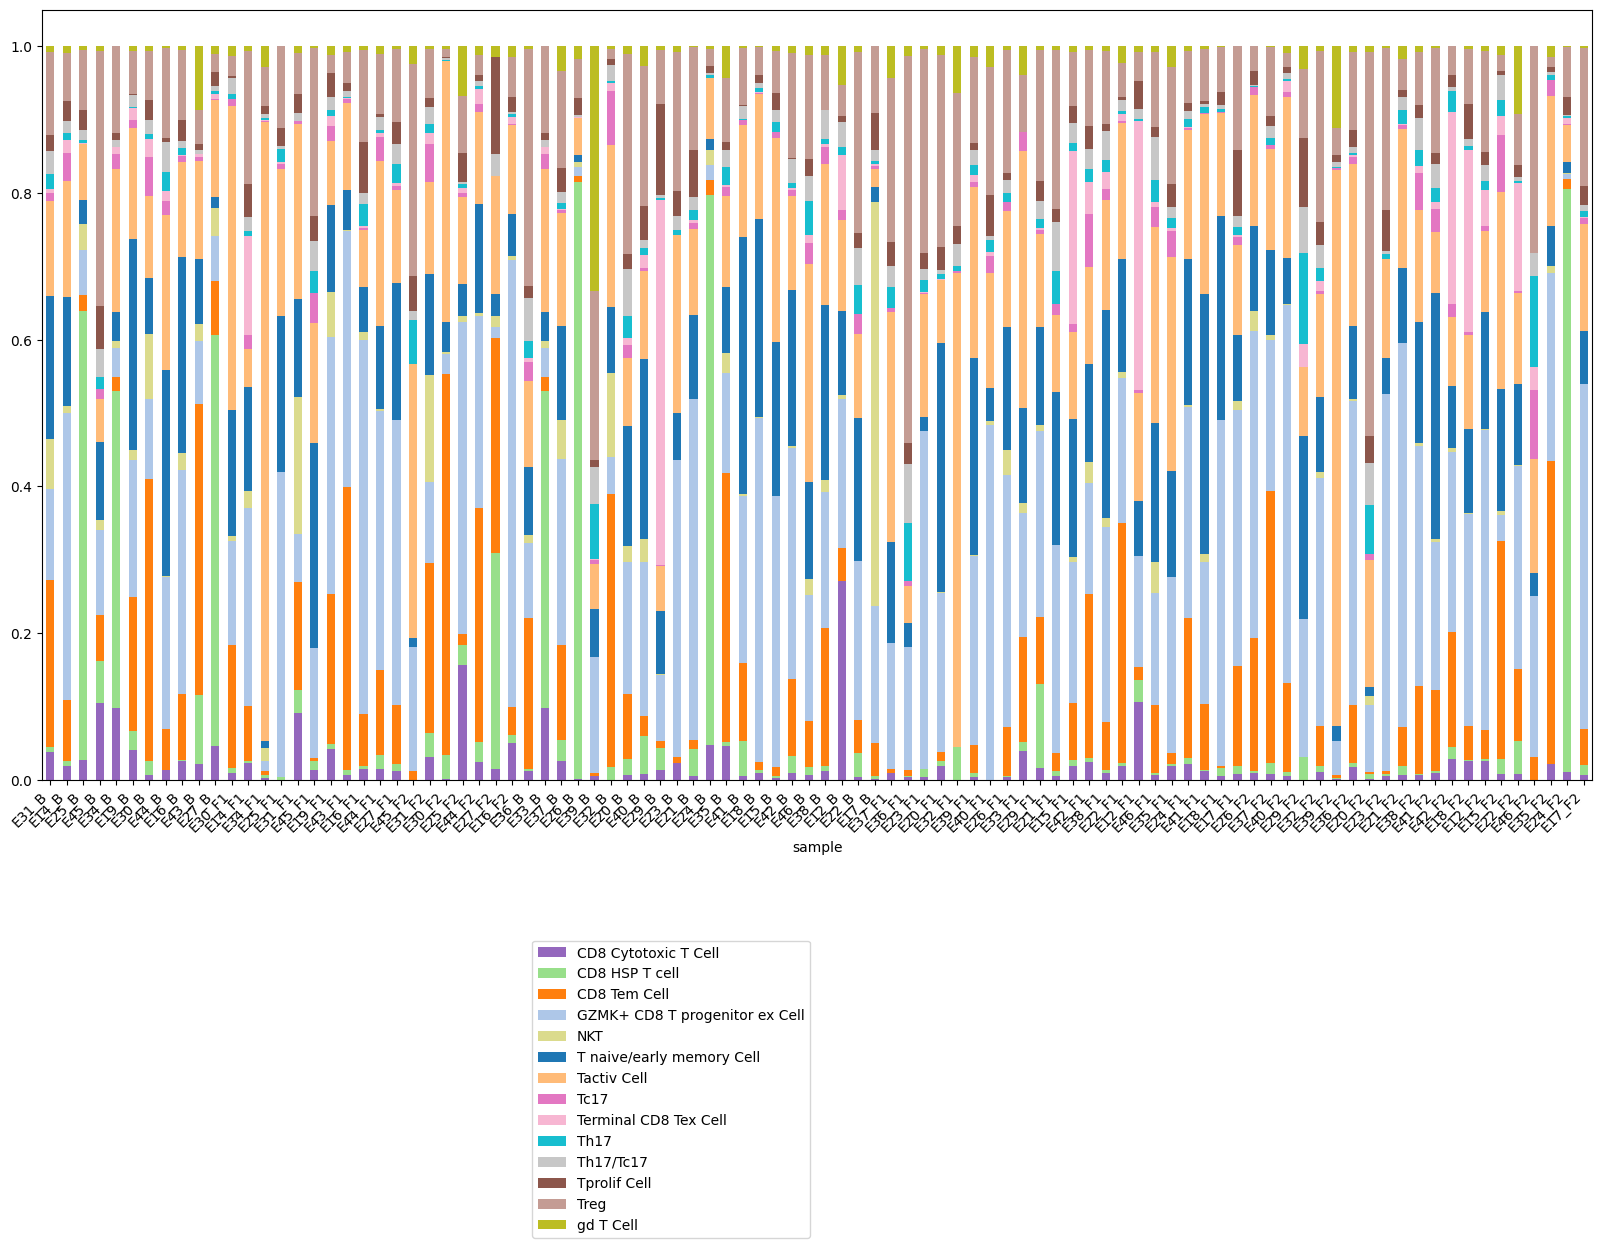

In [16]:
sample_cell_counts.loc[sample_order].plot(kind='bar',stacked=True,color=color_dict,figsize=(20,10))
plt.legend(bbox_to_anchor=(0.5,-0.2))
plt.xticks(rotation=45,ha='right')

In [17]:
adata_sub.obs['progression'] = adata_sub.obs['patient'].map(
    progression_dict
)

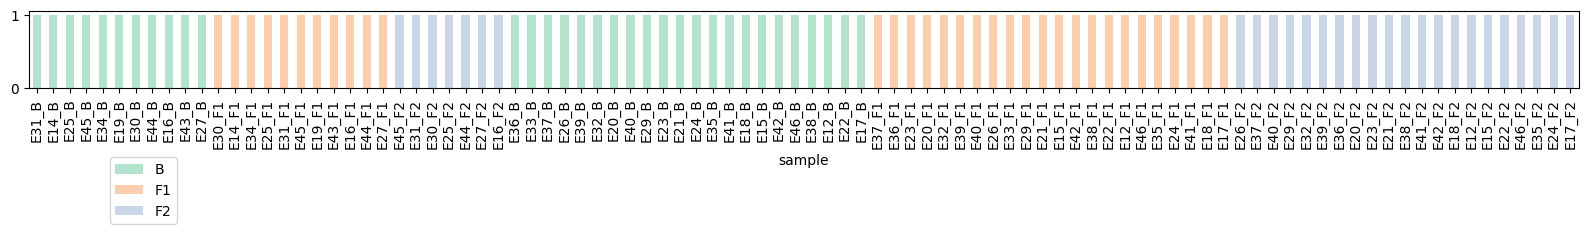

In [18]:
adata_sub.obs[[
    'sample','timepoint']].drop_duplicates().value_counts().reset_index().pivot(
    columns='timepoint',index='sample',values=0
    ).fillna(0).loc[sample_order].plot(kind='bar',stacked=True,figsize=(20,1),
                                      color = {'B':'#b3e2cd',
                                               'F1':'#fdcdac',
                                               'F2':'#cbd5e8'})
plt.legend(bbox_to_anchor=(0.1,-0.8))

In [19]:
import matplotlib.colors as mcolors
cmap = plt.cm.Pastel2

# The colormap has 8 distinct colors. 
# We can retrieve them by sampling the colormap at specific points.
# For qualitative colormaps like Pastel2, it's common to sample 
# at evenly spaced intervals or at the specific points provided by the colormap.
# For Pastel2, there are 8 distinct colors, so we can sample at 8 points.
num_colors = 8
[mcolors.to_hex(cmap(i / (num_colors - 1))) for i in range(num_colors)]

['#b3e2cd',
 '#fdcdac',
 '#cbd5e8',
 '#f4cae4',
 '#e6f5c9',
 '#fff2ae',
 '#f1e2cc',
 '#cccccc']

In [20]:
meta = pd.read_excel('/home/jupyter/data/ge_korea/raw_data/CAPOX-Pem_Patient_withTCGA.xlsx',sheet_name='HER2 Negative')

In [21]:
subtype = pd.Series(meta['TCGA Subtype (0 = Indeterminate, 1 = GS, 2 = CIN, 3 = MSI-High, 4 = EBV'].values, index=meta['Subject No']).to_dict()

In [22]:
adata_sub.obs['subtype_numeric'] = adata_sub.obs['patient'].map(subtype)
adata.obs['subtype_numeric'] = adata.obs['patient'].map(subtype)

In [23]:
adata_sub.obs['subtype']=adata_sub.obs['subtype_numeric'].map({0 : 'Indeterminate',
                                                               1 : 'GS',
                                                               2 : 'CIN',
                                                               3 : 'MSI-High',
                                                               4 : 'EBV'})
adata.obs['subtype']=adata.obs['subtype_numeric'].map({0 : 'Indeterminate',
                                                               1 : 'GS',
                                                               2 : 'CIN',
                                                               3 : 'MSI-High',
                                                               4 : 'EBV'})

In [24]:
adata_sub.obs['subtype'].value_counts()

GS          47224
CIN         45595
MSI-High     6443
EBV          4632
Name: subtype, dtype: int64

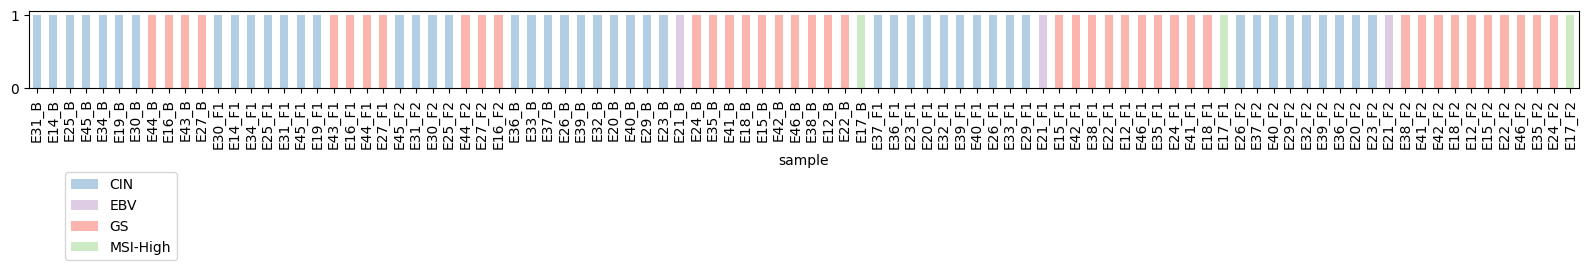

In [25]:
adata_sub.obs[[
    'sample','subtype']].drop_duplicates().value_counts().reset_index().pivot(
    columns='subtype',index='sample',values=0,
    ).fillna(0).loc[sample_order].plot(kind='bar',stacked=True,figsize=(20,1),color={'GS' : '#fbb4ae', 
                                                                   'CIN' : '#b3cde3', 
                                                                   'MSI-High' : '#ccebc5',
                                                                   'EBV' : '#decbe4'})
plt.legend(bbox_to_anchor=(0.1,-1))

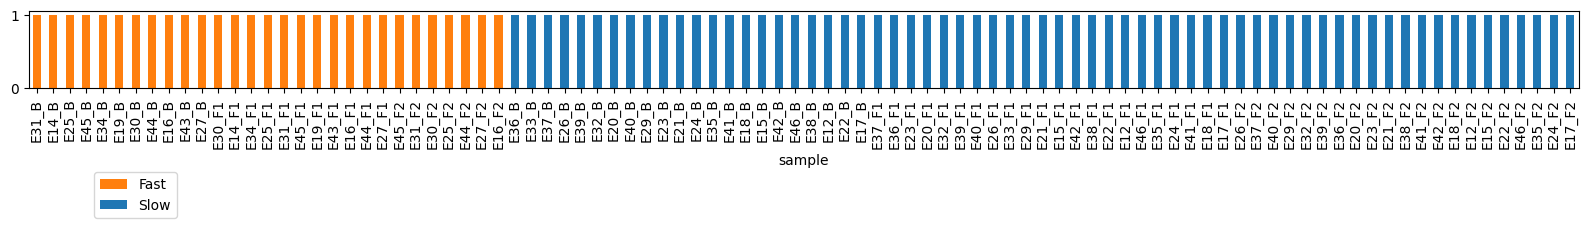

In [26]:
adata_sub.obs[[
    'sample','progression']].drop_duplicates().value_counts().reset_index().pivot(
    columns='progression',index='sample',values=0,
    ).fillna(0).loc[sample_order].plot(kind='bar',stacked=True,figsize=(20,1),color={'Fast' : 'tab:orange',
                                                                                     'Slow' : 'tab:blue'})
plt.legend(bbox_to_anchor=(0.1,-1))

# CIN

In [27]:
sample_cell_counts = adata[(adata.obs['annot_final_new_try'] != 'NK') & ~(
    adata.obs['normal'].isin(['AN','DN'])) & (adata.obs['subtype'].isin(['CIN']))].obs[[
    'annot_final_new_try','sample']].value_counts().reset_index().pivot(
    columns='annot_final_new_try',index='sample',values=0).fillna(0)
sample_cell_counts = sample_cell_counts.div(sample_cell_counts.sum(axis=1),axis=0)

In [28]:
adata_sub = adata[~(adata.obs['normal'].isin(['AN','DN'])) & (adata.obs['subtype'].isin(['CIN']))]

In [29]:
adata_sub.obs['progression'] = adata_sub.obs['patient'].map(
    progression_dict
)

/tmp/ipykernel_149003/1452649840.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs['progression'] = adata_sub.obs['patient'].map(


In [30]:
sample_order = adata_sub.obs[['timepoint','progression','sample']].drop_duplicates(
        
).sort_values(by=['progression','timepoint'])['sample'].tolist()

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]),
 [Text(0, 0, 'E31_B'),
  Text(1, 0, 'E14_B'),
  Text(2, 0, 'E25_B'),
  Text(3, 0, 'E45_B'),
  Text(4, 0, 'E34_B'),
  Text(5, 0, 'E19_B'),
  Text(6, 0, 'E30_B'),
  Text(7, 0, 'E30_F1'),
  Text(8, 0, 'E14_F1'),
  Text(9, 0, 'E34_F1'),
  Text(10, 0, 'E25_F1'),
  Text(11, 0, 'E31_F1'),
  Text(12, 0, 'E45_F1'),
  Text(13, 0, 'E19_F1'),
  Text(14, 0, 'E45_F2'),
  Text(15, 0, 'E31_F2'),
  Text(16, 0, 'E30_F2'),
  Text(17, 0, 'E25_F2'),
  Text(18, 0, 'E36_B'),
  Text(19, 0, 'E33_B'),
  Text(20, 0, 'E37_B'),
  Text(21, 0, 'E26_B'),
  Text(22, 0, 'E39_B'),
  Text(23, 0, 'E32_B'),
  Text(24, 0, 'E20_B'),
  Text(25, 0, 'E40_B'),
  Text(26, 0, 'E29_B'),
  Text(27, 0, 'E23_B'),
  Text(28, 0, 'E37_F1'),
  Text(29, 0, 'E36_F1'),
  Text(30, 0, 'E23_F1'),
  Text(31, 0, 'E20_F1'),
  Text(32, 0,

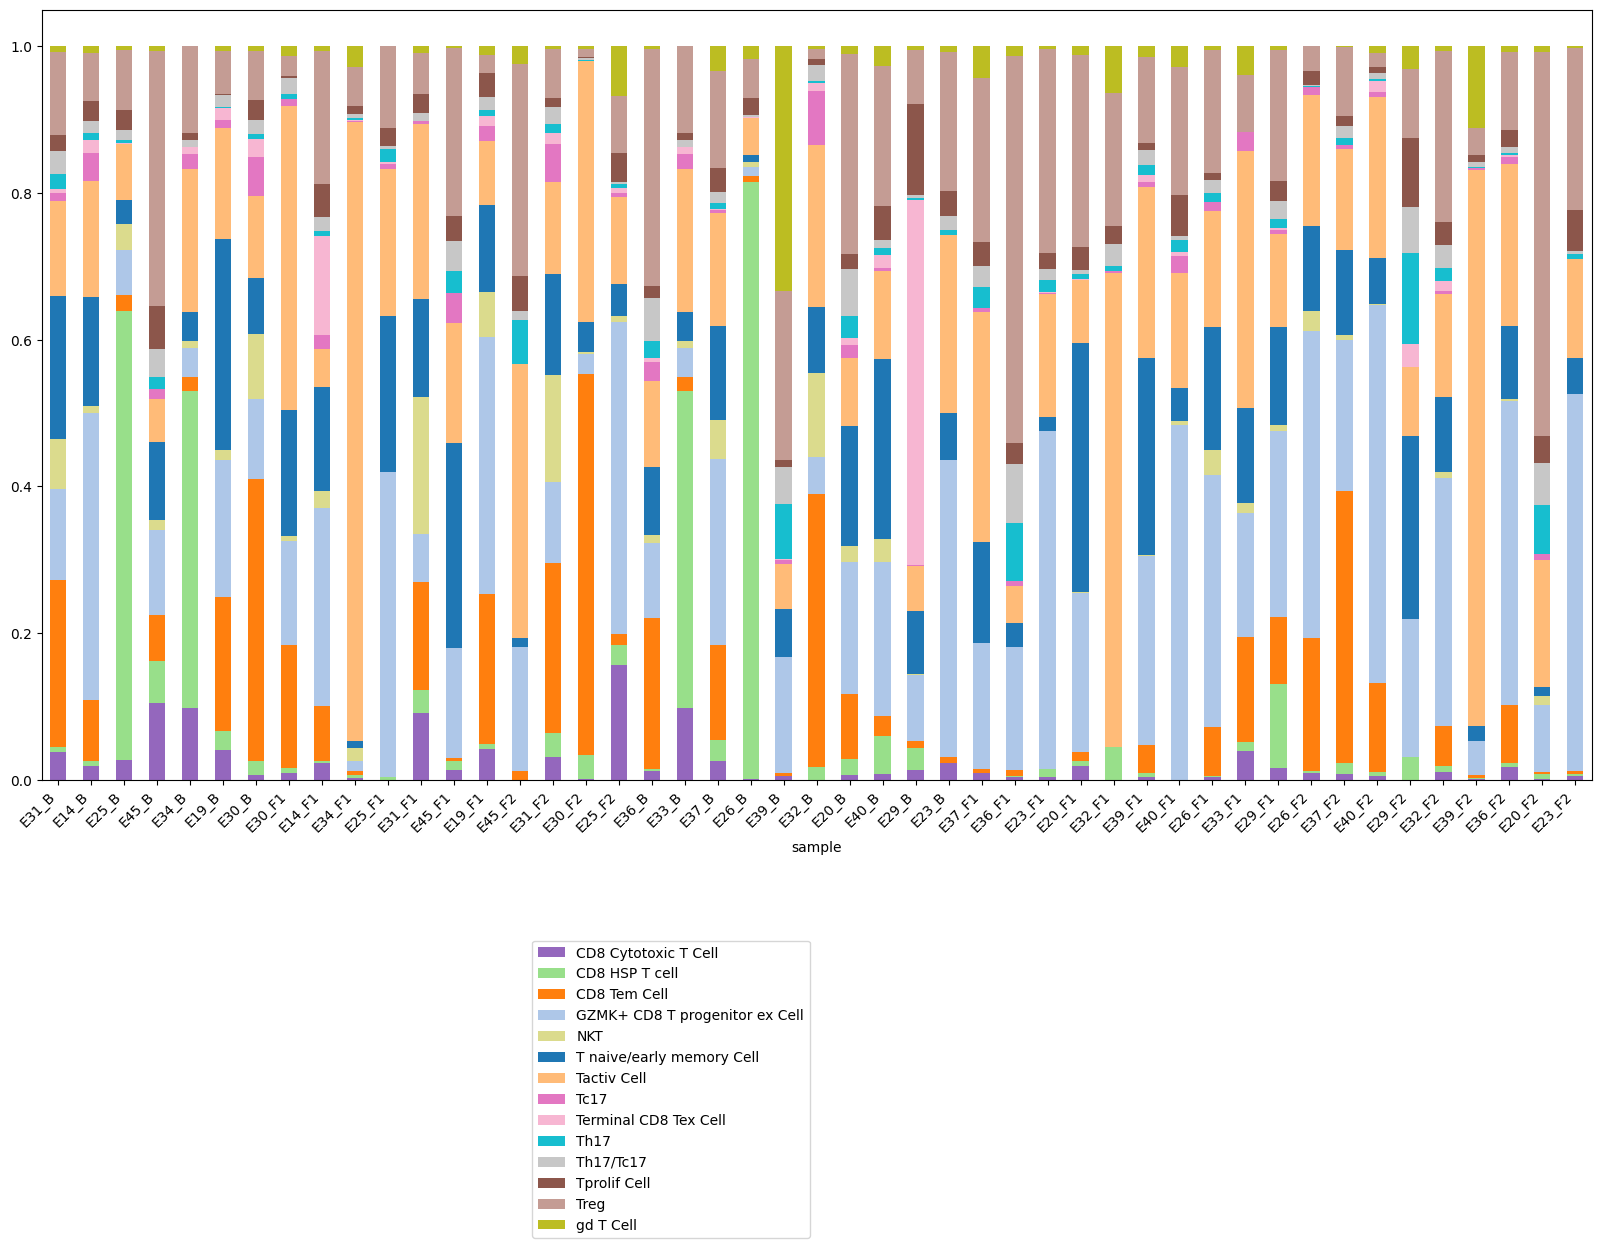

In [31]:
sample_cell_counts.loc[sample_order].plot(kind='bar',stacked=True,color=color_dict,figsize=(20,10))
plt.legend(bbox_to_anchor=(0.5,-0.2))
plt.xticks(rotation=45,ha='right')

In [32]:
adata_sub.obs['progression'] = adata_sub.obs['patient'].map(
    progression_dict
)

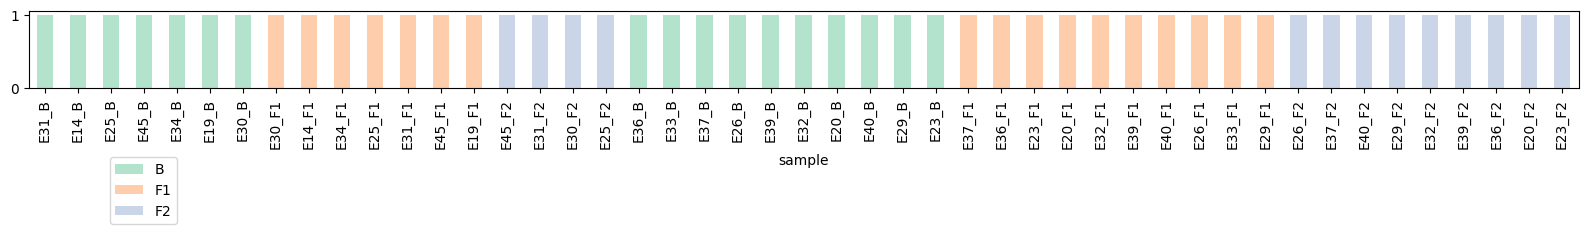

In [33]:
adata_sub.obs[[
    'sample','timepoint']].drop_duplicates().value_counts().reset_index().pivot(
    columns='timepoint',index='sample',values=0
    ).fillna(0).loc[sample_order].plot(kind='bar',stacked=True,figsize=(20,1),
                                      color = {'B':'#b3e2cd',
                                               'F1':'#fdcdac',
                                               'F2':'#cbd5e8'})
plt.legend(bbox_to_anchor=(0.1,-0.8))

In [34]:
import matplotlib.colors as mcolors
cmap = plt.cm.Pastel2

# The colormap has 8 distinct colors. 
# We can retrieve them by sampling the colormap at specific points.
# For qualitative colormaps like Pastel2, it's common to sample 
# at evenly spaced intervals or at the specific points provided by the colormap.
# For Pastel2, there are 8 distinct colors, so we can sample at 8 points.
num_colors = 8
[mcolors.to_hex(cmap(i / (num_colors - 1))) for i in range(num_colors)]

['#b3e2cd',
 '#fdcdac',
 '#cbd5e8',
 '#f4cae4',
 '#e6f5c9',
 '#fff2ae',
 '#f1e2cc',
 '#cccccc']

In [35]:
meta = pd.read_excel('/home/jupyter/data/ge_korea/raw_data/CAPOX-Pem_Patient_withTCGA.xlsx',sheet_name='HER2 Negative')

In [36]:
subtype = pd.Series(meta['TCGA Subtype (0 = Indeterminate, 1 = GS, 2 = CIN, 3 = MSI-High, 4 = EBV'].values, index=meta['Subject No']).to_dict()

In [37]:
adata_sub.obs['subtype_numeric'] = adata_sub.obs['patient'].map(subtype)

In [38]:
adata_sub.obs['subtype']=adata_sub.obs['subtype_numeric'].map({0 : 'Indeterminate',
                                                               1 : 'GS',
                                                               2 : 'CIN',
                                                               3 : 'MSI-High',
                                                               4 : 'EBV'})

In [39]:
adata_sub.obs['subtype'].value_counts()

CIN    45595
Name: subtype, dtype: int64

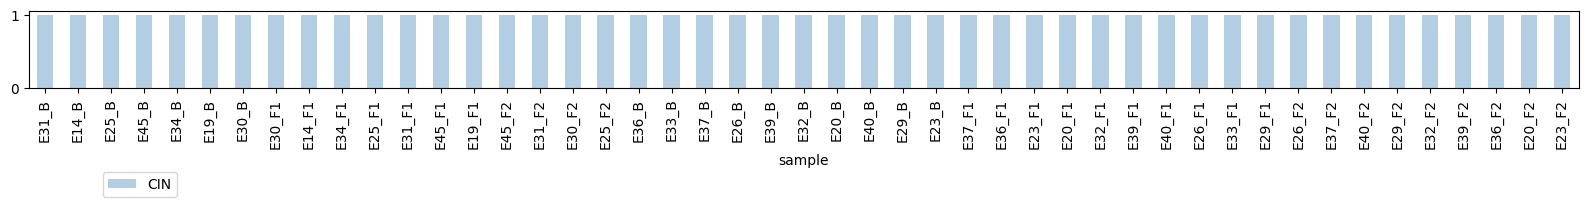

In [40]:
adata_sub.obs[[
    'sample','subtype']].drop_duplicates().value_counts().reset_index().pivot(
    columns='subtype',index='sample',values=0,
    ).fillna(0).loc[sample_order].plot(kind='bar',stacked=True,figsize=(20,1),color={'GS' : '#fbb4ae', 
                                                                   'CIN' : '#b3cde3', 
                                                                   'MSI-High' : '#ccebc5',
                                                                   'EBV' : '#decbe4'})
plt.legend(bbox_to_anchor=(0.1,-1))

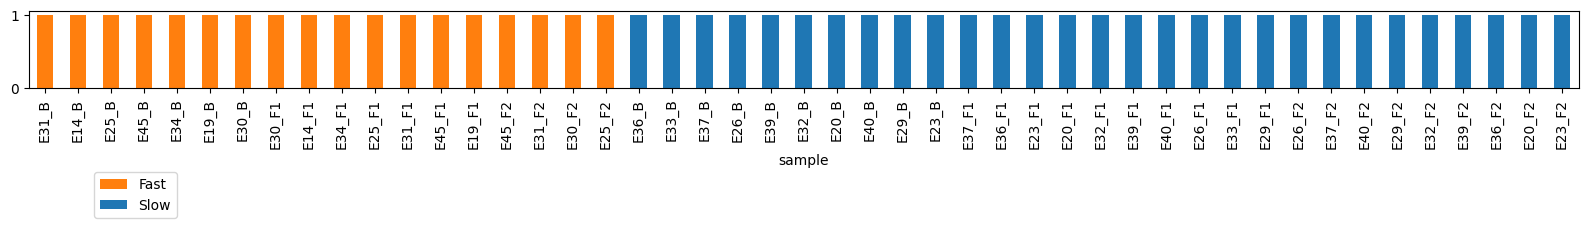

In [41]:
adata_sub.obs[[
    'sample','progression']].drop_duplicates().value_counts().reset_index().pivot(
    columns='progression',index='sample',values=0,
    ).fillna(0).loc[sample_order].plot(kind='bar',stacked=True,figsize=(20,1),color={'Fast' : 'tab:orange',
                                                                                     'Slow' : 'tab:blue'})
plt.legend(bbox_to_anchor=(0.1,-1))

# GS

In [42]:
sample_cell_counts = adata[(adata.obs['annot_final_new_try'] != 'NK') & ~(
    adata.obs['normal'].isin(['AN','DN'])) & (adata.obs['subtype'].isin(['GS']))].obs[[
    'annot_final_new_try','sample']].value_counts().reset_index().pivot(
    columns='annot_final_new_try',index='sample',values=0).fillna(0)
sample_cell_counts = sample_cell_counts.div(sample_cell_counts.sum(axis=1),axis=0)

In [43]:
adata_sub = adata[~(adata.obs['normal'].isin(['AN','DN'])) & (adata.obs['subtype'].isin(['GS']))]

In [44]:
adata_sub.obs['progression'] = adata_sub.obs['patient'].map(
    progression_dict
)

/tmp/ipykernel_149003/1452649840.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs['progression'] = adata_sub.obs['patient'].map(


In [45]:
sample_order = adata_sub.obs[['timepoint','progression','sample']].drop_duplicates(
        
).sort_values(by=['progression','timepoint'])['sample'].tolist()

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40]),
 [Text(0, 0, 'E44_B'),
  Text(1, 0, 'E16_B'),
  Text(2, 0, 'E43_B'),
  Text(3, 0, 'E27_B'),
  Text(4, 0, 'E43_F1'),
  Text(5, 0, 'E16_F1'),
  Text(6, 0, 'E44_F1'),
  Text(7, 0, 'E27_F1'),
  Text(8, 0, 'E44_F2'),
  Text(9, 0, 'E27_F2'),
  Text(10, 0, 'E16_F2'),
  Text(11, 0, 'E24_B'),
  Text(12, 0, 'E35_B'),
  Text(13, 0, 'E41_B'),
  Text(14, 0, 'E18_B'),
  Text(15, 0, 'E15_B'),
  Text(16, 0, 'E42_B'),
  Text(17, 0, 'E46_B'),
  Text(18, 0, 'E38_B'),
  Text(19, 0, 'E12_B'),
  Text(20, 0, 'E22_B'),
  Text(21, 0, 'E15_F1'),
  Text(22, 0, 'E42_F1'),
  Text(23, 0, 'E38_F1'),
  Text(24, 0, 'E22_F1'),
  Text(25, 0, 'E12_F1'),
  Text(26, 0, 'E46_F1'),
  Text(27, 0, 'E35_F1'),
  Text(28, 0, 'E24_F1'),
  Text(29, 0, 'E41_F1'),
  Text(30, 0, 'E18_F1'),
  Text(31, 0, 'E38_F2'),
  Text(32, 0, 'E41_F2'),
  Text(33

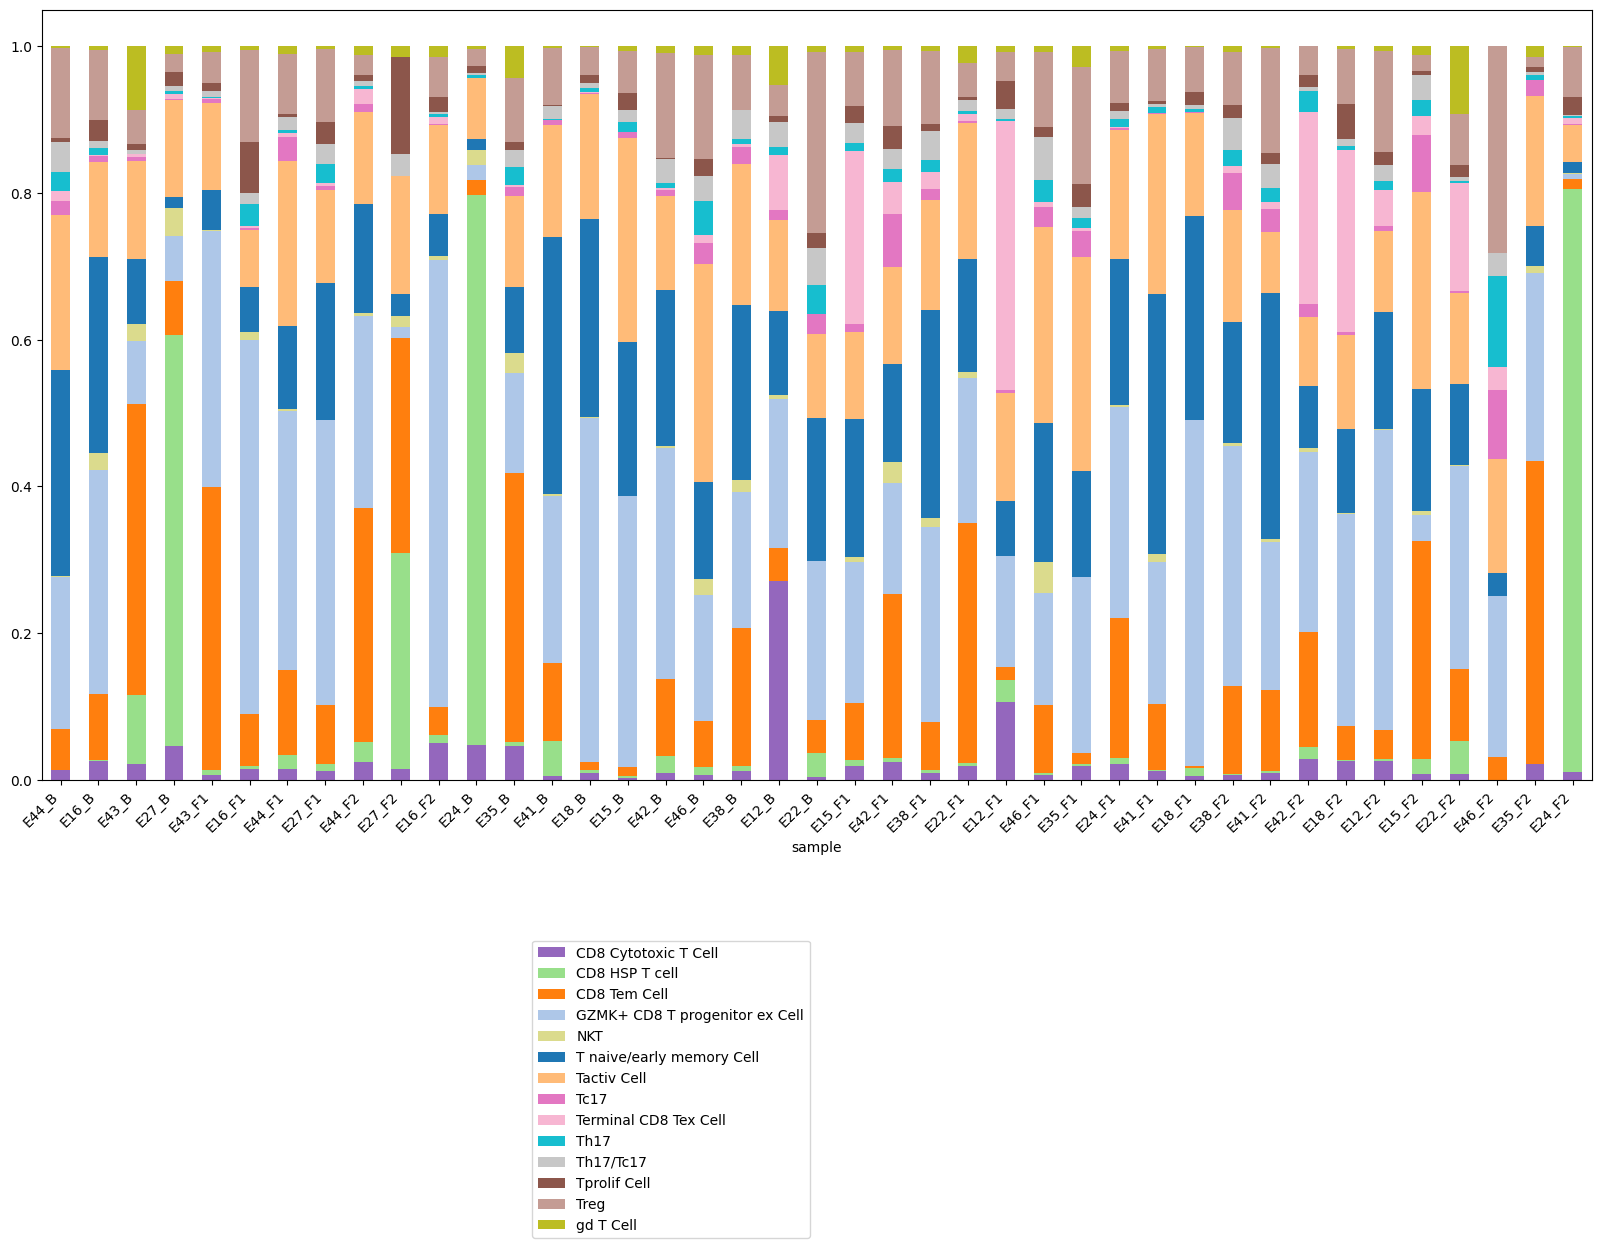

In [46]:
sample_cell_counts.loc[sample_order].plot(kind='bar',stacked=True,color=color_dict,figsize=(20,10))
plt.legend(bbox_to_anchor=(0.5,-0.2))
plt.xticks(rotation=45,ha='right')

In [47]:
adata_sub.obs['progression'] = adata_sub.obs['patient'].map(
    progression_dict
)

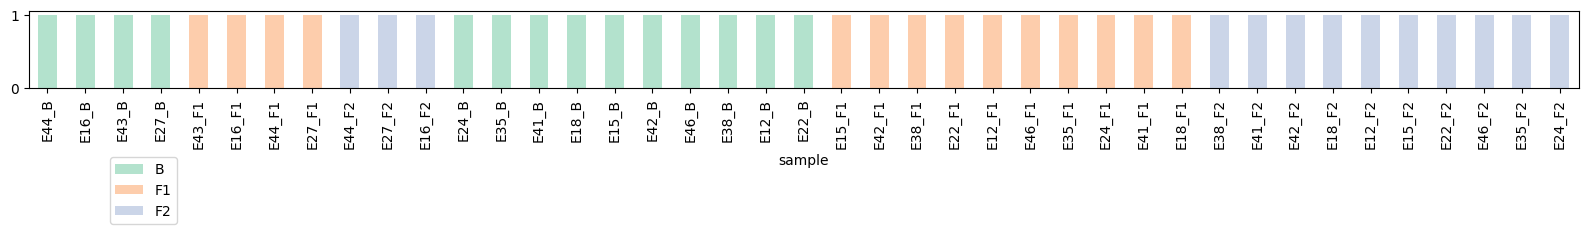

In [48]:
adata_sub.obs[[
    'sample','timepoint']].drop_duplicates().value_counts().reset_index().pivot(
    columns='timepoint',index='sample',values=0
    ).fillna(0).loc[sample_order].plot(kind='bar',stacked=True,figsize=(20,1),
                                      color = {'B':'#b3e2cd',
                                               'F1':'#fdcdac',
                                               'F2':'#cbd5e8'})
plt.legend(bbox_to_anchor=(0.1,-0.8))

In [49]:
import matplotlib.colors as mcolors
cmap = plt.cm.Pastel2

# The colormap has 8 distinct colors. 
# We can retrieve them by sampling the colormap at specific points.
# For qualitative colormaps like Pastel2, it's common to sample 
# at evenly spaced intervals or at the specific points provided by the colormap.
# For Pastel2, there are 8 distinct colors, so we can sample at 8 points.
num_colors = 8
[mcolors.to_hex(cmap(i / (num_colors - 1))) for i in range(num_colors)]

['#b3e2cd',
 '#fdcdac',
 '#cbd5e8',
 '#f4cae4',
 '#e6f5c9',
 '#fff2ae',
 '#f1e2cc',
 '#cccccc']

In [50]:
meta = pd.read_excel('/home/jupyter/data/ge_korea/raw_data/CAPOX-Pem_Patient_withTCGA.xlsx',sheet_name='HER2 Negative')

In [51]:
subtype = pd.Series(meta['TCGA Subtype (0 = Indeterminate, 1 = GS, 2 = CIN, 3 = MSI-High, 4 = EBV'].values, index=meta['Subject No']).to_dict()

In [52]:
adata_sub.obs['subtype_numeric'] = adata_sub.obs['patient'].map(subtype)

In [53]:
adata_sub.obs['subtype']=adata_sub.obs['subtype_numeric'].map({0 : 'Indeterminate',
                                                               1 : 'GS',
                                                               2 : 'CIN',
                                                               3 : 'MSI-High',
                                                               4 : 'EBV'})

In [54]:
adata_sub.obs['subtype'].value_counts()

GS    47224
Name: subtype, dtype: int64

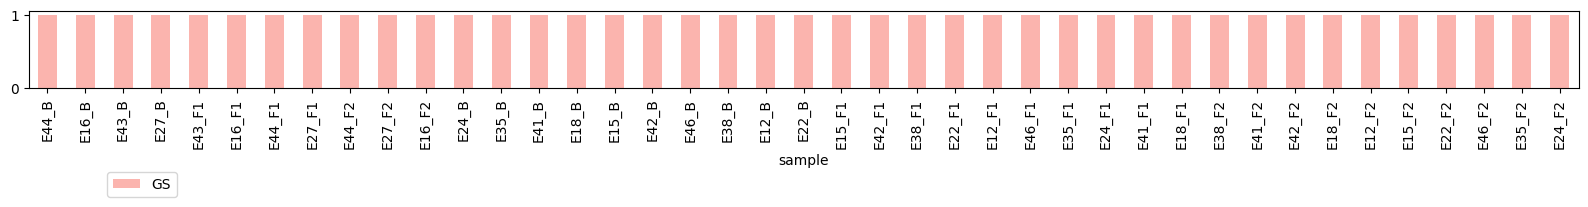

In [55]:
adata_sub.obs[[
    'sample','subtype']].drop_duplicates().value_counts().reset_index().pivot(
    columns='subtype',index='sample',values=0,
    ).fillna(0).loc[sample_order].plot(kind='bar',stacked=True,figsize=(20,1),color={'GS' : '#fbb4ae', 
                                                                   'CIN' : '#b3cde3', 
                                                                   'MSI-High' : '#ccebc5',
                                                                   'EBV' : '#decbe4'})
plt.legend(bbox_to_anchor=(0.1,-1))

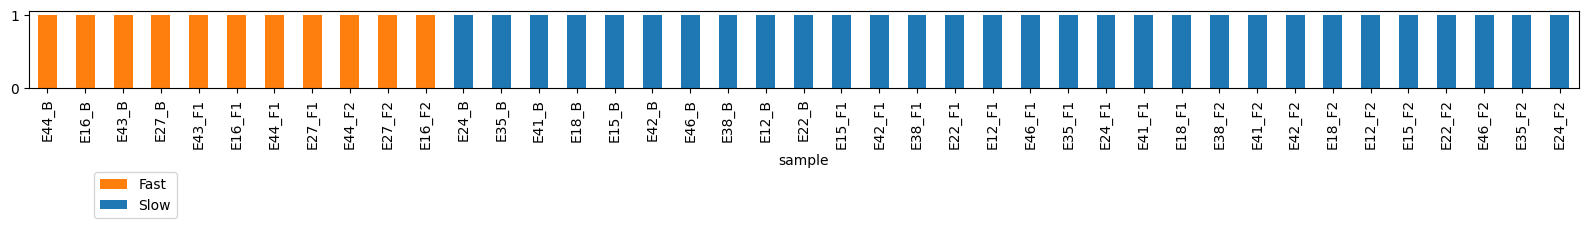

In [56]:
adata_sub.obs[[
    'sample','progression']].drop_duplicates().value_counts().reset_index().pivot(
    columns='progression',index='sample',values=0,
    ).fillna(0).loc[sample_order].plot(kind='bar',stacked=True,figsize=(20,1),color={'Fast' : 'tab:orange',
                                                                                     'Slow' : 'tab:blue'})
plt.legend(bbox_to_anchor=(0.1,-1))